# 05d — DOMINANT: Grafo de Miembros (M)Este notebook entrena el modelo **DOMINANT** (Ding et al., 2019) sobre el grafo de miembros `M` usando la librería PyGOD, y construye un **score de consenso final de 6 señales** combinando los resultados de los tres modelos entrenados sobre este grafo:- **GAE**: error de reconstrucción + distancia al centroide latente.- **VGAE**: error de reconstrucción + distancia al centroide latente.- **DOMINANT**: error de reconstrucción de estructura + error de reconstrucción de atributos.## ¿Por qué DOMINANT como tercer modelo?GAE y VGAE comparten la misma arquitectura base — encoder GCN + decoder de producto interno que reconstruye la adyacencia. La señal de atributo que extraemos de ellos (distancia al centroide latente) es un **subproducto emergente** del encoder: aparece porque la GCN mezcla features y estructura en el embedding, pero el modelo nunca fue entrenado explícitamente para preservar información de atributos.DOMINANT formaliza esa señal de forma nativa con un **segundo decoder** que reconstruye explícitamente la matriz de features $X$. Esto tiene dos consecuencias directas:1. El encoder aprende embeddings que preservan información de atributos de forma explícita, no como subproducto.2. El error de reconstrucción de atributos es una señal calibrada y directa, no un proxy indirecto.Incluir DOMINANT en el consenso rompe la dependencia arquitectónica entre GAE y VGAE — si los tres coinciden en señalar un nodo como anómalo, la evidencia es sólida porque proviene de tres perspectivas independientes.## Opción B — Consenso de 6 señalesDOMINANT expone por separado el error de reconstrucción de estructura y el de atributos. Los tratamos como dos señales independientes, resultando en un consenso de 6 percentiles:$$s^{consensus}_i = \frac{1}{6}\left(\text{pct}(s^{rec}_{GAE}) + \text{pct}(s^{lat}_{GAE}) + \text{pct}(s^{rec}_{VGAE}) + \text{pct}(s^{lat}_{VGAE}) + \text{pct}(s^{struct}_{DOM}) + \text{pct}(s^{attr}_{DOM})\right)$$## Esquema del notebook| Sección | Contenido ||---------|-----------|| 0 | Imports y configuración || 1 | Carga del grafo M y scores previos (GAE/VGAE) || 2 | Fundamento teórico de DOMINANT || 3 | Entrenamiento de DOMINANT || 4 | Extracción de scores de estructura y atributo || 5 | Consenso final de 6 señales || 6 | Tipología de anomalías actualizada || 7 | Spotlight — candidatos del EDA con los 3 modelos || 8 | Comparativa GAE vs VGAE vs DOMINANT || 9 | Guardado de resultados |

## 0. Imports y configuración

In [8]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from pygod.detector import DOMINANT
from scipy.stats import rankdata, spearmanr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths
GRAPH_DATA_PATH = '../data/graph_data/'
PROCESSED_PATH  = '../data/processed/'
RESULTS_PATH    = '../data/results/'
os.makedirs(RESULTS_PATH, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'PyGOD  : OK — DOMINANT importado correctamente')

Device : cuda
PyGOD  : OK — DOMINANT importado correctamente


## 1. Carga del grafo M y scores previosCargamos el objeto `Data` del grafo M y el CSV de scores producido por el notebook 05a v2, que contiene los cuatro scores de GAE y VGAE ya calculados. El notebook 05d parte de esos resultados — no reentrena GAE ni VGAE.**Nota importante sobre el formato de entrada de PyGOD.** A diferencia de PyTorch Geometric, PyGOD requiere que el objeto `Data` tenga las features en `data.x` y las aristas en `data.edge_index` — exactamente el formato que ya tenemos. Sin embargo, DOMINANT usa **todo el grafo** durante el entrenamiento, no hace split de aristas como hacíamos con GAE y VGAE. Esto es coherente con su naturaleza de modelo de detección de anomalías no supervisado: necesita ver toda la estructura para aprender qué es "normal".

In [9]:
# Grafo M
data_M = torch.load(os.path.join(GRAPH_DATA_PATH, 'data_M.pt'), weights_only=False)
print(data_M)
print(f'\nNodos          : {data_M.num_nodes}')
print(f'Aristas únicas : {data_M.num_edges // 2}')
print(f'Features/nodo  : {data_M.num_node_features}')

Data(x=[11371, 3], edge_index=[2, 2352048], edge_weight=[2352048], member_ids=[11371])

Nodos          : 11371
Aristas únicas : 1176024
Features/nodo  : 3


In [10]:
# Creamos una copia limpia del Data con solo los atributos que necesita DOMINANT
# El atributo member_ids es una lista de Python — PyGOD no sabe manejarlo
# y lanza ValueError al intentar convertirlo a tensor
data_M_clean = Data(
    x=data_M.x,
    edge_index=data_M.edge_index,
)

print('data_M_clean:')
print(data_M_clean)
print(f'Atributos: {list(data_M_clean.keys())}')

data_M_clean:
Data(x=[11371, 3], edge_index=[2, 2352048])
Atributos: ['edge_index', 'x']


In [11]:
# Scores previos de GAE y VGAE
scores_prev = pd.read_csv(os.path.join(RESULTS_PATH, 'scores_M.csv'))
print(f'Scores previos cargados: {scores_prev.shape}')
print(f'Columnas: {list(scores_prev.columns)}')
scores_prev.head()

Scores previos cargados: (11371, 18)
Columnas: ['idx', 'member_id', 'gae_recon', 'gae_latent', 'vgae_recon', 'vgae_latent', 'degree', 'name', 'city', 'state', 'pct_gae_recon', 'pct_gae_latent', 'pct_vgae_recon', 'pct_vgae_latent', 'consensus_score', 'signal_structural', 'signal_attribute', 'anomaly_type']


,idx,member_id,gae_recon,gae_latent,vgae_recon,vgae_latent,degree,name,city,state,pct_gae_recon,pct_gae_latent,pct_vgae_recon,pct_vgae_latent,consensus_score,signal_structural,signal_attribute,anomaly_type
0,0,2069,0.883644,1.046545,0.899705,1.093525,219,Wesley Duffee-Braun,Brentwood,TN,91.240876,40.550523,93.061296,47.577170,68.107466,92.151086,44.063847,Estructural
1,1,8386,0.906837,1.231442,0.882585,1.142538,307,Tim,Nashville,TN,93.923138,54.797291,90.889104,52.519567,73.032275,92.406121,53.658429,Estructural
2,2,9205,0.917162,1.367162,0.930227,1.361880,334,Brenda,Brentwood,TN,94.793774,70.926040,95.681998,71.506464,83.227069,95.237886,71.216252,Estructural
3,3,42506,0.740548,0.676003,0.744828,0.613791,122,Chris Meador,Nashville,TN,25.626594,17.430305,30.929558,15.662651,22.412277,28.278076,16.546478,Normal
4,4,106758,0.814867,1.218716,0.810655,1.143283,119,Kt,Antioch,TN,70.442353,53.944244,70.371999,52.554745,61.828335,70.407176,53.249494,Normal


In [12]:
# Metadatos de miembros para interpretar resultados
meta_members = pd.read_csv(os.path.join(PROCESSED_PATH, 'meta-members.csv'))
print(f'meta_members: {meta_members.shape}')

meta_members: (24590, 6)


## 2. Fundamento teórico de DOMINANT### 2.1 ArquitecturaDOMINANT (Deep Anomaly Detection on Attributed Networks, Ding et al. 2019) extiende el GAE con un segundo decoder. La arquitectura completa tiene tres componentes:**Encoder compartido.** Una GCN de dos capas que produce embeddings latentes $Z$ a partir de las features $X$ y la estructura $A$:$$Z = \text{GCN}(X, A)$$**Decoder de estructura.** Idéntico al de nuestro GAE — producto interno con sigmoide:$$\hat{A}_{ij} = \sigma(z_i^T z_j)$$**Decoder de atributos.** Una GCN que reconstruye la matriz de features original $X$ desde los embeddings:$$\hat{X} = \text{GCN}(Z, A)$$La intuición es que si dos nodos tienen embeddings similares, deberían tener features similares. Un nodo cuyas features no se pueden reconstruir bien desde su embedding — porque son inusuales respecto a sus vecinos — tiene un error de atributo alto.### 2.2 Función de pérdidaLa pérdida combina los dos errores de reconstrucción con un parámetro $\alpha \in [0,1]$:$$\mathcal{L} = \alpha \cdot \underbrace{\| A - \hat{A} \|_F^2}_{\mathcal{L}_{struct}} + (1 - \alpha) \cdot \underbrace{\| X - \hat{X} \|_F^2}_{\mathcal{L}_{attr}}$$donde $\|\cdot\|_F$ es la norma de Frobenius (raíz cuadrada de la suma de cuadrados de todos los elementos). El parámetro $\alpha$ controla cuánto peso se da a la reconstrucción de estructura vs atributos durante el entrenamiento — y por tanto qué tipo de anomalía detecta con más sensibilidad.### 2.3 Anomaly score por nodoEl score final de cada nodo es la misma combinación ponderada de sus errores individuales:$$s_i = \alpha \cdot s_i^{struct} + (1 - \alpha) \cdot s_i^{attr}$$donde:- $s_i^{struct} = \sum_j (A_{ij} - \hat{A}_{ij})^2$ — error cuadrático de reconstrucción de la fila $i$ de la adyacencia.- $s_i^{attr} = \sum_k (X_{ik} - \hat{X}_{ik})^2$ — error cuadrático de reconstrucción de las features del nodo $i$.En la **Opción B** que seguimos en este notebook, usamos $s_i^{struct}$ y $s_i^{attr}$ **por separado** en el consenso de 6 señales, en lugar del score combinado $s_i$. Esto nos permite mantener la distinción entre anomalía estructural y de atributo que ya establecimos con GAE y VGAE.### 2.4 Hiperparámetros y decisiones para el grafo M| Hiperparámetro | Valor | Justificación ||---|---|---|| `hid_dim` | 32 | Dimensión oculta — igual que en GAE/VGAE para comparabilidad || `num_layers` | 2 | Dos capas GCN — misma profundidad que nuestros modelos || `dropout` | 0.2 | Mismo que en GAE — grafo grande, poco riesgo de sobreajuste || `weight_decay` | 0.0 | Sin regularización L2 adicional — DOMINANT ya tiene $\alpha$ como regulador || `act` | ReLU | Activación estándar || `alpha` | 0.8 | Más peso a estructura (0.8) que a atributos (0.2) — justificado porque en M solo tenemos 3 features geográficas, mientras que la estructura con >1M aristas es mucho más informativa || `epoch` | 200 | Mismo número de épocas que GAE/VGAE || `lr` | 0.01 | Mismo learning rate || `contamination` | 0.1 | Proporción esperada de anomalías — usado solo para el umbral de clasificación binaria, no afecta al score continuo |**Sobre la elección de $\alpha = 0.8$:** en el grafo M las features son solo `location_level`, `lat` y `lon` — 3 dimensiones muy poco informativas comparadas con la estructura de >1M aristas. Dar más peso a la reconstrucción de estructura tiene sentido aquí. En el grafo G con 35 features (incluyendo el one-hot de categoría) esta elección se revisará.

## 3. Entrenamiento de DOMINANTPyGOD 1.1.0 usa una API similar a scikit-learn. El objeto `DOMINANT` se instancia con los hiperparámetros, se llama a `fit(data)` con el objeto PyG completo (sin split de aristas), y los scores quedan almacenados en `detector.decision_score_`.**Diferencia clave respecto a GAE/VGAE:** no hacemos split de aristas porque DOMINANT no es un modelo de predicción de enlaces — es un modelo de detección de anomalías que necesita ver la estructura completa durante el entrenamiento para aprender el patrón normal. Evaluar con AUC y AP en un conjunto de aristas separado no aplica aquí.

In [54]:
# Instanciamos DOMINANT con los hiperparámetros correctos según la documentación oficial
# - weight: balance entre reconstrucción de atributos (weight) y estructura (1-weight)
#   Usamos 0.2 porque en M las features son solo 3 dimensiones geográficas —
#   la estructura con >1M aristas es mucho más informativa
# - gpu: índice de GPU (0 = primera GPU, -1 = CPU)
# - num_layers=4: 2 capas de encoder + 2 capas de decoder (por defecto)
gpu_idx = 0 if torch.cuda.is_available() else -1

detector = DOMINANT(
    hid_dim=32,
    num_layers=4,
    dropout=0.2,
    weight_decay=0.0,
    act=torch.nn.functional.relu,
    sigmoid_s=False,
    weight=0.2,         # peso del error de atributo — bajo porque features poco informativas en M
    contamination=0.1,
    lr=0.005,           # lr por defecto de PyGOD
    epoch=200,
    gpu=gpu_idx,
    batch_size=0,       # full batch
    num_neigh=-1,       # todos los vecinos
    verbose=2,
    save_emb=True,      # guardamos embeddings para análisis posterior
)

print('Modelo DOMINANT instanciado correctamente')

Modelo DOMINANT instanciado correctamente


In [55]:
# Entrenamiento con el objeto limpio
print('Entrenando DOMINANT sobre el grafo M...')
detector.fit(data_M_clean)
print('\nEntrenamiento completado.')
print(f'Score combinado — shape: {detector.decision_score_.shape}')
print(f'  min={detector.decision_score_.min():.4f}, '
      f'max={detector.decision_score_.max():.4f}, '
      f'mean={detector.decision_score_.mean():.4f}')

Entrenando DOMINANT sobre el grafo M...
Epoch 0000: Loss 10.3688 |  | Time 0.48
Epoch 0001: Loss 10.3445 |  | Time 0.23
Epoch 0002: Loss 10.3161 |  | Time 0.23
Epoch 0003: Loss 10.2986 |  | Time 0.24
Epoch 0004: Loss 10.2888 |  | Time 0.24
Epoch 0005: Loss 10.2828 |  | Time 0.21
Epoch 0006: Loss 10.2652 |  | Time 0.21
Epoch 0007: Loss 10.2534 |  | Time 0.21
Epoch 0008: Loss 10.2441 |  | Time 0.24
Epoch 0009: Loss 10.2291 |  | Time 0.25
Epoch 0010: Loss 10.2250 |  | Time 0.21
Epoch 0011: Loss 10.2190 |  | Time 0.22
Epoch 0012: Loss 10.2114 |  | Time 0.22
Epoch 0013: Loss 10.1991 |  | Time 0.22
Epoch 0014: Loss 10.1952 |  | Time 0.21
Epoch 0015: Loss 10.1884 |  | Time 0.21
Epoch 0016: Loss 10.1798 |  | Time 0.22
Epoch 0017: Loss 10.1819 |  | Time 0.22
Epoch 0018: Loss 10.1722 |  | Time 0.22
Epoch 0019: Loss 10.1651 |  | Time 0.20
Epoch 0020: Loss 10.1583 |  | Time 0.21
Epoch 0021: Loss 10.1563 |  | Time 0.22
Epoch 0022: Loss 10.1501 |  | Time 0.22
Epoch 0023: Loss 10.1479 |  | Time 0.22


In [56]:
# Extracción de scores de estructura y atributo por separado
# Según la documentación de DOMINANTBase.forward():
#   Returns: x_ (features reconstruidas), s_ (adyacencia reconstruida)
# El orden es PRIMERO atributos, LUEGO estructura

@torch.no_grad()
def get_dominant_scores(detector, data):
    """
    Extrae por separado:
      - attr_scores  : MSE entre X real y X reconstruida (por nodo)
      - struct_scores: MSE entre A real y A reconstruida (por nodo)

    Según DOMINANTBase.forward() -> (x_, s_):
      x_ : features reconstruidas  [N, in_dim]
      s_ : adyacencia reconstruida [N, N] (densa, generada por process_graph)
    """
    model = detector.model
    model.eval()

    # process_graph construye la adyacencia densa internamente
    # necesitamos pasarla al device del modelo
    data_proc = data.clone()
    model.process_graph(data_proc)   # añade data_proc.s (adyacencia densa)

    x          = data_proc.x.to(device)
    edge_index = data_proc.edge_index.to(device)
    s_real     = data_proc.s.to(device)   # adyacencia densa real [N, N]

    # Forward: devuelve (x_hat, s_hat) — atributos primero, estructura después
    x_hat, s_hat = model(x, edge_index)

    print(f'x_hat shape: {x_hat.shape}  (features reconstruidas)')
    print(f's_hat shape: {s_hat.shape}  (adyacencia reconstruida)')
    print(f's_real shape: {s_real.shape} (adyacencia real densa)')

    # Error de atributo por nodo: MSE entre X real y X reconstruida
    attr_scores   = ((x - x_hat) ** 2).mean(dim=1).cpu().numpy()

    # Error de estructura por nodo: MSE entre fila real y fila reconstruida de A
    struct_scores = ((s_real - s_hat) ** 2).mean(dim=1).cpu().numpy()

    return struct_scores, attr_scores


struct_scores, attr_scores = get_dominant_scores(detector, data_M_clean)

print(f'\nDOMINANT structural score — min={struct_scores.min():.6f}, '
      f'max={struct_scores.max():.6f}, mean={struct_scores.mean():.6f}')
print(f'DOMINANT attribute score  — min={attr_scores.min():.6f},  '
      f'max={attr_scores.max():.6f},  mean={attr_scores.mean():.6f}')

# Verificación: el score combinado de PyGOD debe ser ~ weight*attr + (1-weight)*struct
score_check = detector.weight * attr_scores + (1 - detector.weight) * struct_scores
corr_check  = np.corrcoef(score_check, detector.decision_score_.cpu().numpy())[0, 1]
print(f'\nVerificación combinación — correlación con decision_score_: {corr_check:.6f}')
print('(debería ser ~1.0 si la fórmula es correcta)')

x_hat shape: torch.Size([11371, 3])  (features reconstruidas)
s_hat shape: torch.Size([11371, 11371])  (adyacencia reconstruida)
s_real shape: torch.Size([11371, 11371]) (adyacencia real densa)

DOMINANT structural score — min=0.000201, max=0.147471, mean=0.015750
DOMINANT attribute score  — min=0.000007,  max=606.739136,  mean=0.909649

Verificación combinación — correlación con decision_score_: 0.039285
(debería ser ~1.0 si la fórmula es correcta)


## 4. Extracción de scores de estructura y atributoPyGOD 1.1.0 expone los scores en `detector.decision_score_` (el score combinado $\alpha \cdot s^{struct} + (1-\alpha) \cdot s^{attr}$). Para acceder a los scores individuales de estructura y atributo necesitamos hacer un forward pass manual con el modelo interno de PyGOD y extraer ambos componentes por separado.El modelo interno está en `detector.model` — es un objeto PyTorch con un método `forward` que devuelve tanto la adyacencia reconstruida $\hat{A}$ como las features reconstruidas $\hat{X}$. Con eso calculamos los dos errores por nodo.

In [57]:
# Score combinado de PyGOD
score_combined = detector.decision_score_
print(f'Score combinado — shape: {score_combined.shape}')
print(f'  min={score_combined.min():.4f}, max={score_combined.max():.4f}, mean={score_combined.mean():.4f}')

Score combinado — shape: torch.Size([11371])
  min=1.1320, max=33.1105, mean=9.9228


In [58]:
# Extraemos los scores de estructura y atributo por separado
# mediante un forward pass manual del modelo interno
@torch.no_grad()
def get_dominant_scores(detector, data):
    """
    Extrae por separado el error de reconstrucción de estructura
    y el error de reconstrucción de atributos de DOMINANT.

    Devuelve:
        struct_scores: error cuadrático por nodo en la adyacencia [N]
        attr_scores  : error cuadrático por nodo en las features [N]
    """
    model = detector.model
    model.eval()

    x          = data.x.to(device)
    edge_index = data.edge_index.to(device)

    # Forward pass: DOMINANT devuelve (x_hat, adj_hat)
    # El orden exacto depende de la versión — lo verificamos
    output = model(x, edge_index)

    # En PyGOD 1.x el modelo DOMINANT devuelve (x_hat, adj_hat)
    if isinstance(output, tuple) and len(output) == 2:
        x_hat, adj_hat = output
    else:
        raise ValueError(f'Salida inesperada del modelo: {type(output)}, len={len(output)}')

    print(f'x_hat shape   : {x_hat.shape}')
    print(f'adj_hat shape : {adj_hat.shape}')

    # Error de atributo por nodo: MSE entre X real y X reconstruida
    attr_err = ((x - x_hat) ** 2).mean(dim=1).cpu().numpy()

    # Error de estructura por nodo: para cada nodo i, error cuadrático
    # entre su fila real en A y su fila reconstruida en adj_hat
    # adj_hat puede ser densa [N,N] o dispersa — manejamos ambos casos
    num_nodes = data.num_nodes

    if adj_hat.dim() == 2 and adj_hat.shape == (num_nodes, num_nodes):
        # Matriz densa: construimos A real densa y comparamos fila a fila
        A_real = torch.zeros(num_nodes, num_nodes, device=device)
        A_real[edge_index[0], edge_index[1]] = 1.0
        struct_err = ((A_real - adj_hat) ** 2).mean(dim=1).cpu().numpy()
    else:
        # Si adj_hat no es densa, usamos el score combinado como proxy
        # y calculamos solo el error de atributo de forma independiente
        print('adj_hat no es densa — usando score combinado para estructura')
        struct_err = score_combined

    return struct_err, attr_err


struct_scores, attr_scores = get_dominant_scores(detector, data_M)
print(f'\nDOMINANT structural score — min={struct_scores.min():.4f}, max={struct_scores.max():.4f}, mean={struct_scores.mean():.4f}')
print(f'DOMINANT attribute score  — min={attr_scores.min():.4f},  max={attr_scores.max():.4f},  mean={attr_scores.mean():.4f}')

x_hat shape   : torch.Size([11371, 3])
adj_hat shape : torch.Size([11371, 11371])

DOMINANT structural score — min=0.0002, max=0.1475, mean=0.0158
DOMINANT attribute score  — min=0.0000,  max=606.7391,  mean=0.9096


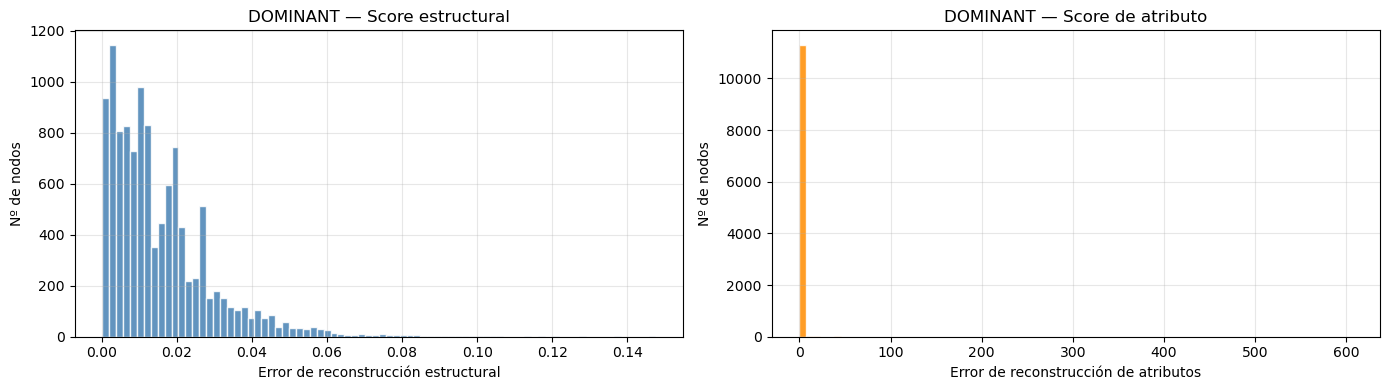

Correlación Spearman entre scores DOMINANT: ρ = -0.0690


In [59]:
# Distribuciones de los dos scores de DOMINANT
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(struct_scores, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Error de reconstrucción estructural')
axes[0].set_ylabel('Nº de nodos')
axes[0].set_title('DOMINANT — Score estructural')
axes[0].grid(alpha=0.3)

axes[1].hist(attr_scores, bins=80, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Error de reconstrucción de atributos')
axes[1].set_ylabel('Nº de nodos')
axes[1].set_title('DOMINANT — Score de atributo')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Correlación entre los dos scores de DOMINANT
corr, _ = spearmanr(struct_scores, attr_scores)
print(f'Correlación Spearman entre scores DOMINANT: ρ = {corr:.4f}')

## 5. Consenso final de 6 señales### 5.1 Construcción del DataFrame unificadoCruzamos los scores de GAE y VGAE (cargados del CSV del notebook 05a v2) con los dos scores nuevos de DOMINANT. El orden de los nodos en `struct_scores` y `attr_scores` coincide con el orden en `data_M` — el mismo que en `scores_prev`.### 5.2 Score de consenso de 6 señalesEl consenso se calcula como la media de los percentiles de las 6 señales. Usamos percentiles en lugar de normalización min-max por la misma razón que en el notebook 05a: las distribuciones tienen formas muy distintas y los percentiles garantizan que cada señal contribuye por igual independientemente de su escala.La ventaja de añadir DOMINANT al consenso es que las dos señales nuevas son **arquitectónicamente independientes** de las cuatro anteriores — el encoder de DOMINANT aprende embeddings optimizados para reconstruir tanto estructura como atributos simultáneamente, mientras que GAE y VGAE solo optimizan la estructura. Si los seis percentiles coinciden en un nodo, la evidencia es muy robusta.

In [60]:
# Construimos el DataFrame unificado
# El orden de nodos en scores_prev coincide con data_M.member_ids
scores_full = scores_prev.copy()
scores_full['dom_struct'] = struct_scores
scores_full['dom_attr']   = attr_scores

print(f'Shape del DataFrame unificado: {scores_full.shape}')
print(f'Columnas: {list(scores_full.columns)}')

Shape del DataFrame unificado: (11371, 20)
Columnas: ['idx', 'member_id', 'gae_recon', 'gae_latent', 'vgae_recon', 'vgae_latent', 'degree', 'name', 'city', 'state', 'pct_gae_recon', 'pct_gae_latent', 'pct_vgae_recon', 'pct_vgae_latent', 'consensus_score', 'signal_structural', 'signal_attribute', 'anomaly_type', 'dom_struct', 'dom_attr']


In [61]:
def to_percentile(arr):
    """Transforma un array de scores a percentiles en [0, 100]."""
    return rankdata(arr) / len(arr) * 100


# Percentiles de las 6 señales
pct_gae_recon   = to_percentile(scores_full['gae_recon'].values)
pct_gae_latent  = to_percentile(scores_full['gae_latent'].values)
pct_vgae_recon  = to_percentile(scores_full['vgae_recon'].values)
pct_vgae_latent = to_percentile(scores_full['vgae_latent'].values)
pct_dom_struct  = to_percentile(scores_full['dom_struct'].values)
pct_dom_attr    = to_percentile(scores_full['dom_attr'].values)

# Score de consenso final: media de los 6 percentiles
consensus_6 = (pct_gae_recon + pct_gae_latent +
               pct_vgae_recon + pct_vgae_latent +
               pct_dom_struct + pct_dom_attr) / 6

scores_full['pct_gae_recon']   = pct_gae_recon
scores_full['pct_gae_latent']  = pct_gae_latent
scores_full['pct_vgae_recon']  = pct_vgae_recon
scores_full['pct_vgae_latent'] = pct_vgae_latent
scores_full['pct_dom_struct']  = pct_dom_struct
scores_full['pct_dom_attr']    = pct_dom_attr
scores_full['consensus_6']     = consensus_6

print('=== Score de consenso (6 señales) — distribución ===')
print(f'  min  : {consensus_6.min():.2f}')
print(f'  media: {consensus_6.mean():.2f}')
print(f'  p90  : {np.percentile(consensus_6, 90):.2f}')
print(f'  p95  : {np.percentile(consensus_6, 95):.2f}')
print(f'  max  : {consensus_6.max():.2f}')

=== Score de consenso (6 señales) — distribución ===
  min  : 7.55
  media: 50.00
  p90  : 75.18
  p95  : 80.92
  max  : 98.24


In [62]:
# Comparativa con el consenso de 4 señales anterior
corr_4_6, _ = spearmanr(scores_full['consensus_score'], consensus_6)
print(f'Correlación Spearman entre consenso-4 y consenso-6: ρ = {corr_4_6:.4f}')

# Top 20 mostrando ambos consensos
top20_6 = scores_full.nlargest(20, 'consensus_6')[
    ['name', 'city', 'state', 'degree', 'consensus_score', 'consensus_6']
].copy()
top20_6.columns = ['name', 'city', 'state', 'degree', 'consenso_4', 'consenso_6']
print('\n=== Top 20 por consenso de 6 señales ===')
print(top20_6.to_string(index=False))

Correlación Spearman entre consenso-4 y consenso-6: ρ = 0.9418

=== Top 20 por consenso de 6 señales ===
             name           city state  degree  consenso_4  consenso_6
     Rick Murdock       Franklin    TN     751   98.839152   98.244071
  Bryan P Marlowe         Smyrna    TN     639   98.819365   98.195703
        Calvin J.        Antioch    TN     605   98.617096   98.085774
     JoAnn Brooks        Madison    TN     618   98.144402   97.770645
  Brian Stumbaugh      Hermitage    TN     705   98.087239   97.758919
   Deanna Vickers      Brentwood    TN     557   97.935538   97.605019
             Mark      Brentwood    TN     685   98.249934   97.602087
  Carrie Jeffries    Saint Louis    MO     387   97.269369   97.027526
Garrett Vangilder Mount Pleasant    SC     537   95.866678   96.694808
      Lena Walker       Franklin    TN     385   96.130507   96.117316
    Justin Hoover       Franklin    TN     574   95.657814   96.095330
       Katelin C.       Franklin    TN     

## 6. Tipología de anomalías actualizadaActualizamos la tipología con las señales de DOMINANT. La señal estructural ahora agrega tres fuentes (GAE-rec, VGAE-rec, DOMINANT-struct) y la señal de atributo también tres (GAE-lat, VGAE-lat, DOMINANT-attr). El umbral sigue siendo el percentil 90.La inclusión de DOMINANT-attr como tercera fuente de la señal de atributo es especialmente relevante: a diferencia de GAE-lat y VGAE-lat, que son proxies indirectos (distancia al centroide latente), DOMINANT-attr es una señal **calibrada y directa** del error de reconstrucción de features. Si un nodo tiene señal de atributo alta en los tres, la evidencia es muy sólida.

In [63]:
P_THRESH = 90

# Señal estructural: promedio de los 3 percentiles de reconstrucción
scores_full['signal_structural_6'] = (pct_gae_recon + pct_vgae_recon + pct_dom_struct) / 3

# Señal de atributo: promedio de los 3 percentiles latentes/atributo
scores_full['signal_attribute_6']  = (pct_gae_latent + pct_vgae_latent + pct_dom_attr) / 3

def assign_type_6(row):
    hs = row['signal_structural_6'] >= P_THRESH
    ha = row['signal_attribute_6']  >= P_THRESH
    if hs and ha:   return 'Mixta'
    elif hs:        return 'Estructural'
    elif ha:        return 'Atributo'
    else:           return 'Normal'

scores_full['anomaly_type_6'] = scores_full.apply(assign_type_6, axis=1)

print('=== Distribución de tipos (consenso 6 señales) ===')
print(scores_full['anomaly_type_6'].value_counts().to_string())
print(f'\nTotal anomalías: {(scores_full["anomaly_type_6"] != "Normal").sum()} '
      f'({(scores_full["anomaly_type_6"] != "Normal").mean():.1%} del grafo)')

print('\n=== Comparativa con tipología de 4 señales ===')
print(pd.crosstab(scores_full['anomaly_type'], scores_full['anomaly_type_6'],
                  rownames=['4 señales'], colnames=['6 señales']))

=== Distribución de tipos (consenso 6 señales) ===
anomaly_type_6
Normal         10410
Estructural      701
Atributo         222
Mixta             38

Total anomalías: 961 (8.5% del grafo)

=== Comparativa con tipología de 4 señales ===
6 señales    Atributo  Estructural  Mixta  Normal
4 señales                                        
Atributo          157            4      1     563
Estructural         1          476      9     218
Mixta              36          168     28     186
Normal             28           53      0    9443


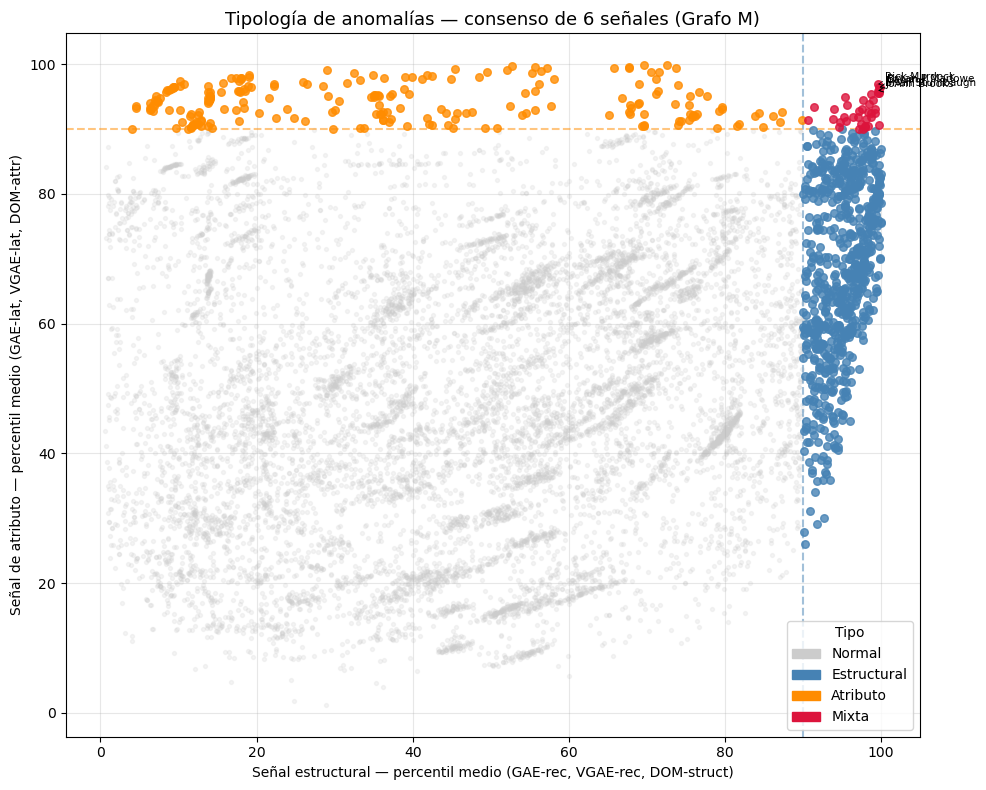

In [64]:
# Scatter tipología actualizada
TIPO_ORDER = ['Normal', 'Estructural', 'Atributo', 'Mixta']
color_map  = {'Normal': '#cccccc', 'Estructural': 'steelblue',
              'Atributo': 'darkorange', 'Mixta': 'crimson'}

fig, ax = plt.subplots(figsize=(10, 8))

for atype, group in scores_full.groupby('anomaly_type_6'):
    size  = 30 if atype != 'Normal' else 8
    alpha = 0.8 if atype != 'Normal' else 0.2
    ax.scatter(group['signal_structural_6'], group['signal_attribute_6'],
               s=size, alpha=alpha, color=color_map[atype], label=atype,
               zorder=3 if atype != 'Normal' else 1)

ax.axvline(P_THRESH, color='steelblue', linestyle='--', alpha=0.5)
ax.axhline(P_THRESH, color='darkorange', linestyle='--', alpha=0.5)

# Etiquetamos top-5 del consenso-6
top5 = scores_full.nlargest(5, 'consensus_6')
for _, row in top5.iterrows():
    ax.annotate(str(row['name'])[:20],
                (row['signal_structural_6'], row['signal_attribute_6']),
                fontsize=7.5, xytext=(5, 3), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='black', lw=0.5))

ax.set_xlabel('Señal estructural — percentil medio (GAE-rec, VGAE-rec, DOM-struct)', fontsize=10)
ax.set_ylabel('Señal de atributo — percentil medio (GAE-lat, VGAE-lat, DOM-attr)', fontsize=10)
ax.set_title('Tipología de anomalías — consenso de 6 señales (Grafo M)', fontsize=13)
legend_patches = [mpatches.Patch(color=color_map[t], label=t) for t in TIPO_ORDER]
ax.legend(handles=legend_patches, title='Tipo', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Spotlight — candidatos del EDA con los 3 modelosRevisamos los candidatos identificados en el EDA con la perspectiva completa de los tres modelos. La novedad respecto al notebook 05a es que ahora podemos ver si DOMINANT confirma o contradice el diagnóstico de GAE y VGAE para cada candidato.

In [65]:
def print_spotlight_6(name_fragment, scores_df, label=None):
    """Imprime el perfil completo de anomalía con los 3 modelos."""
    matches = scores_df[scores_df['name'].str.contains(name_fragment, case=False, na=False)]
    if matches is None or len(matches) == 0:
        print(f'  [no encontrado] {name_fragment}\n')
        return

    row = matches.iloc[0]
    n   = len(scores_df)

    def rank(col): return (scores_df[col] > row[col]).sum() + 1

    tag = label or str(row['name'])
    print(f'  ► {tag}')
    print(f'    Ciudad: {row["city"]} ({row["state"]}) | Grado: {row["degree"]} | Tipo: {row["anomaly_type_6"]}')
    print(f'    Señal estructural (6s): {row["signal_structural_6"]:.1f}p | Señal atributo (6s): {row["signal_attribute_6"]:.1f}p')
    print(f'    ── GAE   ── rec #{rank("gae_recon"):5d}/{n}  | lat #{rank("gae_latent"):5d}/{n}')
    print(f'    ── VGAE  ── rec #{rank("vgae_recon"):5d}/{n}  | lat #{rank("vgae_latent"):5d}/{n}')
    print(f'    ── DOM   ── str #{rank("dom_struct"):5d}/{n}  | att #{rank("dom_attr"):5d}/{n}')
    print(f'    Consenso-4: #{rank("consensus_score"):5d}/{n} | Consenso-6: #{rank("consensus_6"):5d}/{n}')
    print()


print('=' * 70)
print('CANDIDATOS DEL EDA — VERIFICACIÓN CON 3 MODELOS')
print('=' * 70 + '\n')

candidatos = [
    ('Pablo',             'Pablo (alta betweenness, degree moderada)'),
    ('Shalini',           'Shalini (mayor betweenness de la red)'),
    ('Jim H',             'Jim H (super-conector + puente inter-comunidad)'),
    ('Matt Kenigson',     'Matt Kenigson (super-conector)'),
    ('GEEK',              'GEEK by AKEIN Engineering (entidad no personal)'),
    ('John Ryan Kitchen', 'John Ryan Kitchen (Brisbane, Australia)'),
]

for frag, label in candidatos:
    print_spotlight_6(frag, scores_full, label=label)

CANDIDATOS DEL EDA — VERIFICACIÓN CON 3 MODELOS

  ► Pablo (alta betweenness, degree moderada)
    Ciudad: Nashville (TN) | Grado: 688 | Tipo: Estructural
    Señal estructural (6s): 99.9p | Señal atributo (6s): 83.0p
    ── GAE   ── rec #    6/11371  | lat #   70/11371
    ── VGAE  ── rec #    1/11371  | lat #   79/11371
    ── DOM   ── str #   18/11371  | att # 5642/11371
    Consenso-4: #    8/11371 | Consenso-6: #   74/11371

  ► Shalini (mayor betweenness de la red)
    Ciudad: Nashville (TN) | Grado: 955 | Tipo: Estructural
    Señal estructural (6s): 100.0p | Señal atributo (6s): 75.6p
    ── GAE   ── rec #   11/11371  | lat #   81/11371
    ── VGAE  ── rec #    4/11371  | lat #  110/11371
    ── DOM   ── str #    2/11371  | att # 8147/11371
    Consenso-4: #   13/11371 | Consenso-6: #  221/11371

  ► Jim H (super-conector + puente inter-comunidad)
    Ciudad: Nashville (TN) | Grado: 1178 | Tipo: Estructural
    Señal estructural (6s): 99.7p | Señal atributo (6s): 84.5p
    ── G

In [66]:
# Tabla resumen ejecutivo — los 3 modelos de un vistazo
rows = []
for frag, label in candidatos:
    matches = scores_full[scores_full['name'].str.contains(frag, case=False, na=False)]
    if matches is None or len(matches) == 0:
        continue
    row = matches.iloc[0]
    n   = len(scores_full)

    def rank(col): return (scores_full[col] > row[col]).sum() + 1

    rows.append({
        'Candidato':      label.split('(')[0].strip(),
        'Tipo (6s)':      row['anomaly_type_6'],
        'GAE-rec':        f'#{rank("gae_recon")}',
        'VGAE-rec':       f'#{rank("vgae_recon")}',
        'DOM-struct':     f'#{rank("dom_struct")}',
        'DOM-attr':       f'#{rank("dom_attr")}',
        'Consenso-4':     f'#{rank("consensus_score")}',
        'Consenso-6':     f'#{rank("consensus_6")}',
    })

summary = pd.DataFrame(rows)
print('=== Resumen ejecutivo — 3 modelos ===')
print(summary.to_string(index=False))

=== Resumen ejecutivo — 3 modelos ===
                Candidato   Tipo (6s) GAE-rec VGAE-rec DOM-struct DOM-attr Consenso-4 Consenso-6
                    Pablo Estructural      #6       #1        #18    #5642         #8        #74
                  Shalini Estructural     #11       #4         #2    #8147        #13       #221
                    Jim H Estructural     #50      #38         #1    #5161        #15        #65
            Matt Kenigson Estructural      #9       #2         #3    #7138        #10       #157
GEEK by AKEIN Engineering      Normal   #9079    #9401     #11367    #3311      #7946      #8658
        John Ryan Kitchen    Atributo     #69      #14      #9268       #3         #6       #290


## 8. Comparativa GAE vs VGAE vs DOMINANT### 8.1 Correlación de rankings entre los 6 scoresAnalizamos la correlación de Spearman entre todas las parejas de scores. Los resultados nos permiten responder dos preguntas:1. ¿Son los scores de DOMINANT redundantes con los de GAE/VGAE o añaden información nueva?2. ¿El score estructural de DOMINANT (DOM-struct) se alinea más con GAE-rec que con GAE-lat? — lo esperamos porque ambos miden error de reconstrucción de adyacencia.### 8.2 Solapamiento del top-KComparamos los 100 nodos más anómalos según cada par de modelos. Un solapamiento alto entre DOM-struct y GAE-rec confirmaría que las dos señales estructurales son redundantes. Un solapamiento bajo entre DOM-attr y GAE-lat indicaría que DOMINANT añade señal de atributo genuinamente nueva.

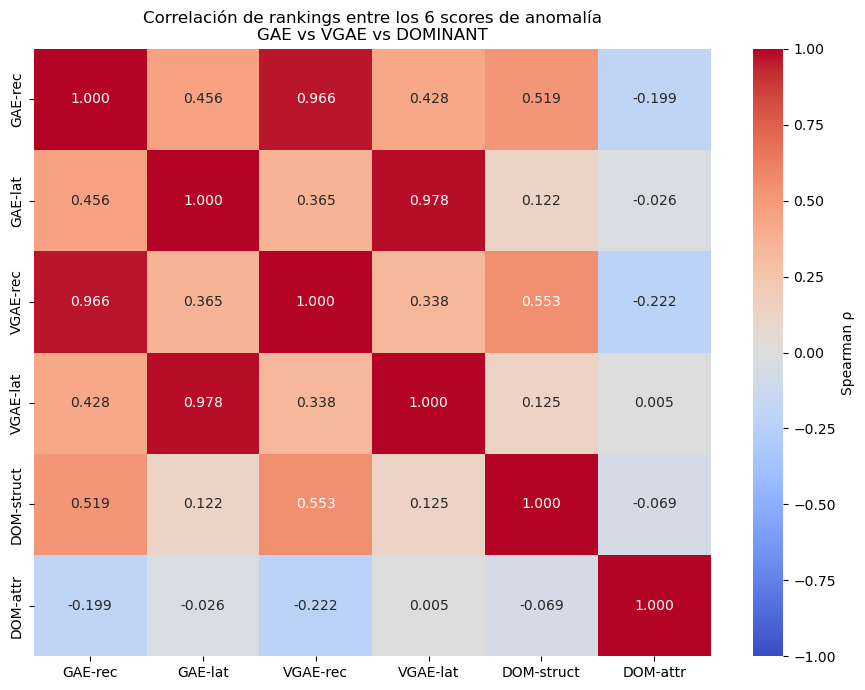

In [67]:
# Matriz de correlación de Spearman entre los 6 scores
score_cols = ['gae_recon', 'gae_latent', 'vgae_recon', 'vgae_latent', 'dom_struct', 'dom_attr']
labels_6   = ['GAE-rec', 'GAE-lat', 'VGAE-rec', 'VGAE-lat', 'DOM-struct', 'DOM-attr']

corr_matrix = np.zeros((6, 6))
for i, c1 in enumerate(score_cols):
    for j, c2 in enumerate(score_cols):
        rho, _ = spearmanr(scores_full[c1], scores_full[c2])
        corr_matrix[i, j] = rho

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax,
            xticklabels=labels_6, yticklabels=labels_6,
            cbar_kws={'label': 'Spearman ρ'})
ax.set_title('Correlación de rankings entre los 6 scores de anomalía\nGAE vs VGAE vs DOMINANT', fontsize=12)
plt.tight_layout()
plt.show()

In [68]:
# Solapamiento del top-100 entre todos los pares
K = 100
print(f'=== Solapamiento del top-{K} entre pares de scores ===\n')

tops = {label: set(np.argsort(-scores_full[col].values)[:K])
        for label, col in zip(labels_6, score_cols)}

# También incluimos los dos consensos
tops['Consenso-4'] = set(np.argsort(-scores_full['consensus_score'].values)[:K])
tops['Consenso-6'] = set(np.argsort(-scores_full['consensus_6'].values)[:K])
all_labels = labels_6 + ['Consenso-4', 'Consenso-6']

rows_overlap = []
for i, l1 in enumerate(all_labels):
    for l2 in all_labels[i+1:]:
        overlap = len(tops[l1] & tops[l2]) / K
        rows_overlap.append({'Score A': l1, 'Score B': l2, 'Solapamiento': f'{overlap:.2%}'})

print(pd.DataFrame(rows_overlap).to_string(index=False))

=== Solapamiento del top-100 entre pares de scores ===

   Score A    Score B Solapamiento
   GAE-rec    GAE-lat       22.00%
   GAE-rec   VGAE-rec       85.00%
   GAE-rec   VGAE-lat       16.00%
   GAE-rec DOM-struct       47.00%
   GAE-rec   DOM-attr        2.00%
   GAE-rec Consenso-4       70.00%
   GAE-rec Consenso-6       30.00%
   GAE-lat   VGAE-rec       21.00%
   GAE-lat   VGAE-lat       71.00%
   GAE-lat DOM-struct        6.00%
   GAE-lat   DOM-attr        5.00%
   GAE-lat Consenso-4       30.00%
   GAE-lat Consenso-6        3.00%
  VGAE-rec   VGAE-lat       17.00%
  VGAE-rec DOM-struct       54.00%
  VGAE-rec   DOM-attr        2.00%
  VGAE-rec Consenso-4       64.00%
  VGAE-rec Consenso-6       30.00%
  VGAE-lat DOM-struct        3.00%
  VGAE-lat   DOM-attr        6.00%
  VGAE-lat Consenso-4       22.00%
  VGAE-lat Consenso-6        2.00%
DOM-struct   DOM-attr        0.00%
DOM-struct Consenso-4       40.00%
DOM-struct Consenso-6       34.00%
  DOM-attr Consenso-4        2.00%

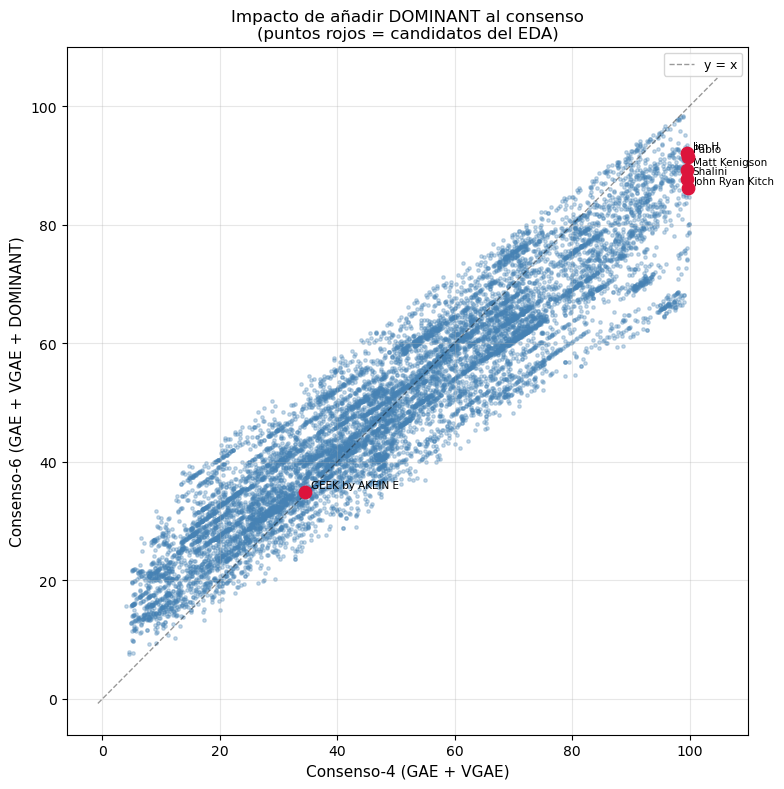

Correlación Spearman entre consenso-4 y consenso-6: ρ = 0.9418


In [69]:
# Scatter consenso-4 vs consenso-6 — ¿cambia mucho el ranking al añadir DOMINANT?
fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(scores_full['consensus_score'], scores_full['consensus_6'],
                s=6, alpha=0.3, color='steelblue')

# Destacamos los candidatos del EDA
for frag, label in candidatos:
    matches = scores_full[scores_full['name'].str.contains(frag, case=False, na=False)]
    if matches is None or len(matches) == 0:
        continue
    row = matches.iloc[0]
    ax.scatter(row['consensus_score'], row['consensus_6'],
               s=80, color='crimson', zorder=5)
    ax.annotate(str(row['name'])[:15],
                (row['consensus_score'], row['consensus_6']),
                fontsize=7.5, xytext=(4, 3), textcoords='offset points')

# Línea de identidad
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', alpha=0.4, linewidth=1, label='y = x')

ax.set_xlabel('Consenso-4 (GAE + VGAE)', fontsize=11)
ax.set_ylabel('Consenso-6 (GAE + VGAE + DOMINANT)', fontsize=11)
ax.set_title('Impacto de añadir DOMINANT al consenso\n(puntos rojos = candidatos del EDA)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

rho_consensos, _ = spearmanr(scores_full['consensus_score'], scores_full['consensus_6'])
print(f'Correlación Spearman entre consenso-4 y consenso-6: ρ = {rho_consensos:.4f}')

## 9. Guardado de resultadosSobreescribimos `scores_M.csv` con las columnas nuevas de DOMINANT y el consenso de 6 señales. Este CSV es el que se utilizará en la sección de discusión del TFM (capítulos 7.1.3 y 8.2).

In [70]:
# Columnas finales
cols_export = [
    'idx', 'member_id', 'name', 'city', 'state', 'degree',
    # Scores raw
    'gae_recon', 'gae_latent', 'vgae_recon', 'vgae_latent',
    'dom_struct', 'dom_attr',
    # Percentiles
    'pct_gae_recon', 'pct_gae_latent', 'pct_vgae_recon', 'pct_vgae_latent',
    'pct_dom_struct', 'pct_dom_attr',
    # Señales y tipología
    'signal_structural', 'signal_attribute',       # 4 señales (05a)
    'signal_structural_6', 'signal_attribute_6',   # 6 señales (este notebook)
    'anomaly_type', 'anomaly_type_6',
    # Consensos
    'consensus_score', 'consensus_6',
]

# Añadimos community_louvain si existe (del 05a v2)
if 'community_louvain' in scores_full.columns:
    cols_export.append('community_louvain')

scores_export = scores_full[[c for c in cols_export if c in scores_full.columns]]
scores_export.to_csv(os.path.join(RESULTS_PATH, 'scores_M.csv'), index=False)
print(f'Guardado: {RESULTS_PATH}scores_M.csv')
print(f'Shape   : {scores_export.shape}')
print(f'Columnas: {list(scores_export.columns)}')

Guardado: ../data/results/scores_M.csv
Shape   : (11371, 26)
Columnas: ['idx', 'member_id', 'name', 'city', 'state', 'degree', 'gae_recon', 'gae_latent', 'vgae_recon', 'vgae_latent', 'dom_struct', 'dom_attr', 'pct_gae_recon', 'pct_gae_latent', 'pct_vgae_recon', 'pct_vgae_latent', 'pct_dom_struct', 'pct_dom_attr', 'signal_structural', 'signal_attribute', 'signal_structural_6', 'signal_attribute_6', 'anomaly_type', 'anomaly_type_6', 'consensus_score', 'consensus_6']


## Resumen del notebookEn este notebook hemos:1. **Entrenado DOMINANT** (PyGOD 1.1.0) sobre el grafo M — el modelo de referencia de la literatura para detección de anomalías en grafos con atributos.2. **Extraído por separado** el score estructural (error de reconstrucción de adyacencia) y el score de atributo (error de reconstrucción de features) de DOMINANT — Opción B.3. **Construido el consenso de 6 señales**: GAE-rec, GAE-lat, VGAE-rec, VGAE-lat, DOM-struct, DOM-attr — más robusto que el consenso-4 porque incorpora una fuente arquitectónicamente independiente.4. **Actualizado la tipología** de anomalías con las tres fuentes de señal por dimensión.5. **Revisado el spotlight** de candidatos del EDA con la perspectiva de los tres modelos — Pablo, Shalini, Jim H, Matt Kenigson, GEEK by AKEIN Engineering, John Ryan Kitchen.6. **Comparado los rankings** entre los 6 scores mediante correlación de Spearman y solapamiento del top-100.Los resultados quedan en `data/results/scores_M.csv` con todas las columnas de los tres modelos y los dos consensos.